# Oscillograms

A probability over a two-dimensional grid of energy and baseline. This is the case broadcasting was built for: the whole map is one call, with no Python loop anywhere.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Building the grid

The trick is the shape of the two arguments. Hamiltonians get a trailing pair of matrix axes and a leading energy axis; baselines get a leading axis of their own. Indexing with `None` lines them up so they broadcast into a grid.

In [2]:
n_e, n_l = 240, 240
E_gev = np.logspace(-1.0, 1.5, n_e)
L_km = np.linspace(50.0, 12000.0, n_l)

H = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, E_gev*GEV, gd.VCC_EARTH_CRUST)

# (n_e, 1, 3, 3) against (1, n_l) -> an (n_e, n_l) grid
p = oscprob3nu.probabilities_3nu(H[:, None, :, :],
                                 (L_km*KM)[None, :])
print("returned shape:", np.shape(p))

returned shape: (240, 240, 9)


## $P_{\mu e}$ over energy and baseline

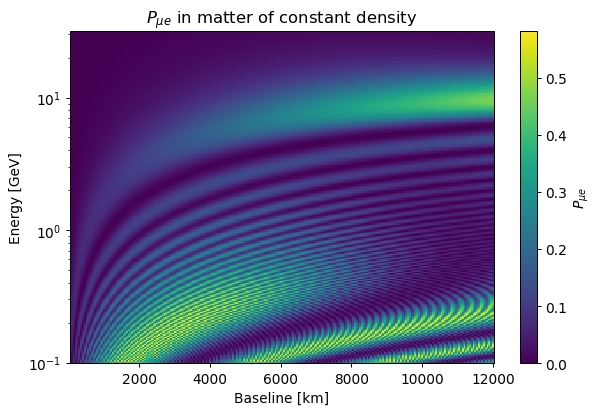

In [3]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
mesh = ax.pcolormesh(L_km, E_gev, p[:, :, 3], shading="auto",
                     cmap="viridis", vmin=0.0)
ax.set_yscale("log")
ax.set_xlabel("Baseline [km]")
ax.set_ylabel("Energy [GeV]")
ax.set_title(r"$P_{\mu e}$ in matter of constant density")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label=r"$P_{\mu e}$")
plt.show()

## Survival, on the same grid

The muon-neutrino survival probability shows the oscillation valleys that atmospheric experiments measure.

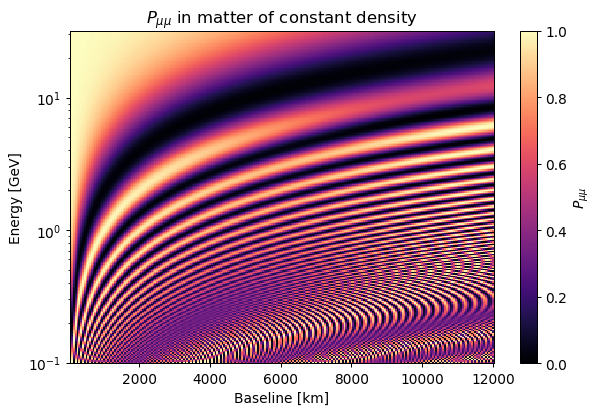

In [4]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
mesh = ax.pcolormesh(L_km, E_gev, p[:, :, 4], shading="auto",
                     cmap="magma", vmin=0.0, vmax=1.0)
ax.set_yscale("log")
ax.set_xlabel("Baseline [km]")
ax.set_ylabel("Energy [GeV]")
ax.set_title(r"$P_{\mu\mu}$ in matter of constant density")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label=r"$P_{\mu\mu}$")
plt.show()

Both maps above are a single call each on a 240 x 240 grid — 57 600 probabilities. Written as a Python loop this is tens of times slower; **notebook 09** measures exactly how much, on whatever machine runs it.

---

**Previous:** [Matter, NSI, and LIV](03_matter_nsi_liv.ipynb)  
**Next:** [Bi-probability plots](05_biprobability.ipynb) --- CP violation, as an ellipse  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)